# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026 — posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit — including a machine's — is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$ — except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs — on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants — and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

Slope: 1.298 ± 0.119
Y-intercept: 47.737 ± 0.718


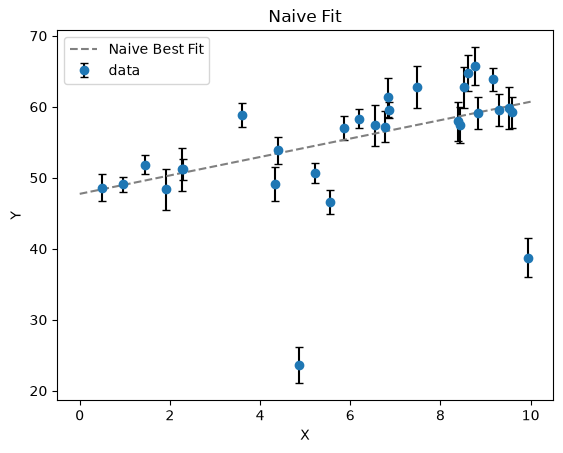

In [274]:
# Part 1: your work here
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt('benh7L1.csv', delimiter = ',', skip_header = 1)
x = data[:, 0]
y = data[:, 1]
sigma = data[:, 2]

plt.errorbar(x, y, yerr = sigma, fmt = 'o', ecolor = 'black', capsize = 3, label = 'data')
plt.title('Naive Fit')

wls = np.polyfit(x, y, 1, w = 1/sigma, cov = 'unscaled')

xx = np.linspace(0, 10, 200)
n_fit = wls[0][0] * xx + wls[0][1]
plt.plot(xx, n_fit, label = 'Naive Best Fit', color = 'grey', linestyle = '--')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

print(f'Slope: {wls[0][0]:.3f} \u00B1 {np.sqrt(wls[1][0][0]):.3f}')
print(f'Y-intercept: {wls[0][1]:.3f} \u00B1 {np.sqrt(wls[1][1][1]):.3f}')

In [275]:
n = len(x)
residuals = y - np.polyval(wls[0], x)
Chi2 = np.sum((residuals/sigma)**2)
Chi2_Reduced = Chi2 / (n - 2)

print(f'Reduced Chi2 value: {Chi2_Reduced:.3f}')

Reduced Chi2 value: 10.535


**ANSWER (a few sentences):**

*The reduced chi-square value is a measure of how closely your data varies about your model. As your residuals decrease and your sigma value shrinks this value approaches 1. As this reduced chi-square value is greater than 10, this model deviates from the model significantly. This deviation makes sense as you can visually see that there are two big outliers in the data. These outliers pull the fitted slope down reducing how well the describes the data. As these two points pull the slope down, I would not fully trust these calculated error bars as they use these outliers in their calculation.*

## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment — this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer** — one set of numbers
you'd put in a paper — and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

Slope: 1.528 ± 0.122
Y-Intercept: 47.989 ± 0.751
Reduced Chi2: 1.181
Outlier Fraction: 0.167 of the data is an outlier


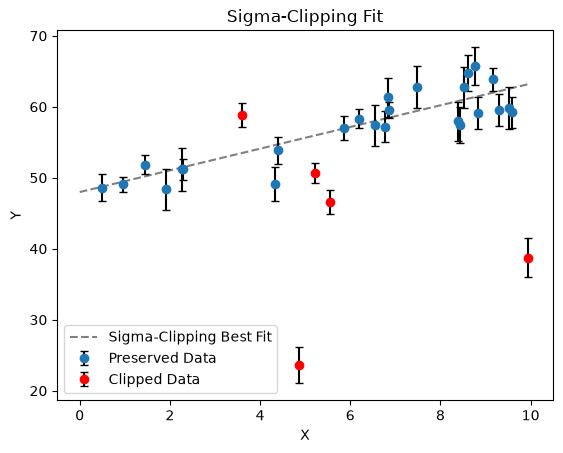

In [297]:
# Part 2: your work here
#Sigma Clipping Model:
def sigma_clip_fit(x, y, sigma, k=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    
    for _ in range(max_iter):
        p = np.polyfit(x[mask], y[mask], 1, w=1/sigma[mask], cov = 'unscaled')
        resid = (y - np.polyval(p[0], x)) / sigma
        new_mask = np.abs(resid) < k
        
        if np.array_equal(new_mask, mask):
            break
            
        mask = new_mask
        
    return p, mask

sc, mask = sigma_clip_fit(x, y, sigma)
sc_fit = xx * sc[0][0] + sc[0][1]

plt.plot(xx, sc_fit, label = 'Sigma-Clipping Best Fit', color = 'grey', linestyle = '--')
plt.errorbar(x[mask], y[mask], yerr = sigma[mask], fmt = 'o', ecolor = 'black', capsize = 3, label = 'Preserved Data')
plt.errorbar(x[~mask], y[~mask], yerr = sigma[~mask],
             color = 'red', fmt = 'o', ecolor = 'black', capsize = 3, label = 'Clipped Data')
plt.title('Sigma-Clipping Fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

Residual_clipped = y[mask] - np.polyval(sc[0], x[mask])
Chi2_Clipped = np.sum((Residual_clipped / sigma[mask])** 2) / (mask.sum() - 2)

print(f'Slope: {sc[0][0]:.3f} \u00B1 {np.sqrt(sc[1][0][0]):.3f}')
print(f'Y-Intercept: {sc[0][1]:.3f} \u00B1 {np.sqrt(sc[1][1][1]):.3f}')
print(f'Reduced Chi2: {Chi2_Clipped:.3f}')
print(f'Outlier Fraction: {(5/30):.3f} of the data is an outlier')

This model uses a 3 sigma threshold for convergence. I chose this threshold as this model would take about 99.7% of the data into consideration assuming that the model is a gaussian centered about the line. As the data visually appeared to be linear, I felt that having this type of 3-sigma cutoff would include most of the data for this kind of model.

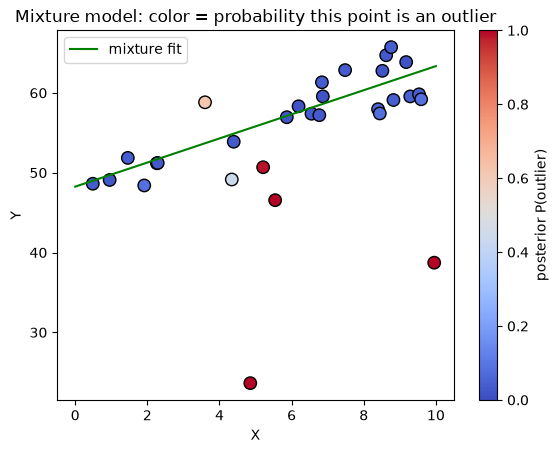

Slope: 1.510
Y-intercept: 48.253
Outlier Fraction: 0.167 of the data is an outlier


In [277]:
#Mixture Model:
from scipy.optimize import minimize
from scipy.stats import norm

def neg_log_likelihood(theta, x, y, sigma):
    m, b, Pb, Yb, lnVb = theta
    Pb = np.clip(Pb, 1e-6, 1 - 1e-6)
    Vb = np.exp(lnVb)
    model = m * x + b
    good = (1 - Pb) * norm.pdf(y, loc=model, scale=sigma)
    bad_pop = Pb * norm.pdf(y, loc=Yb, scale=np.sqrt(Vb + sigma**2))
    return -np.sum(np.log(good + bad_pop + 1e-300))

# start from the sigma-clip fit, a sensible and defensible initial guess
theta0 = [sc[0][0], sc[0][1], 5/30, np.mean(y), np.log(50.0)]
result = minimize(neg_log_likelihood, theta0, args=(x, y, sigma), method='Nelder-Mead')
m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x

Vb_mix = np.exp(lnVb_mix)
model_mix = m_mix * x + b_mix
good_l = (1 - Pb_mix) * norm.pdf(y, loc=model_mix, scale=sigma)
bad_l = Pb_mix * norm.pdf(y, loc=Yb_mix, scale=np.sqrt(Vb_mix + sigma**2))
p_bad = bad_l / (good_l + bad_l)

plt.scatter(x, y, c=p_bad, cmap='coolwarm', s=80, edgecolor='k', vmin=0, vmax=1)
plt.colorbar(label='posterior P(outlier)')
plt.plot(xx, m_mix * xx + b_mix, 'g-', label='mixture fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Mixture model: color = probability this point is an outlier')
plt.legend()
plt.show()

print(f'Slope: {m_mix:.3f}')
print(f'Y-intercept: {b_mix:.3f}')

prob_bad = len(p_bad[p_bad >= .5])
print(f'Outlier Fraction: {(prob_bad/30):.3f} of the data is an outlier')

bootstrap 68% interval slopes = [1.36, 1.64]
Slope range: ± 0.138

bootstrap 68% interval Y-intercepts = [47.58, 49.10]
Slope range: ± 0.759


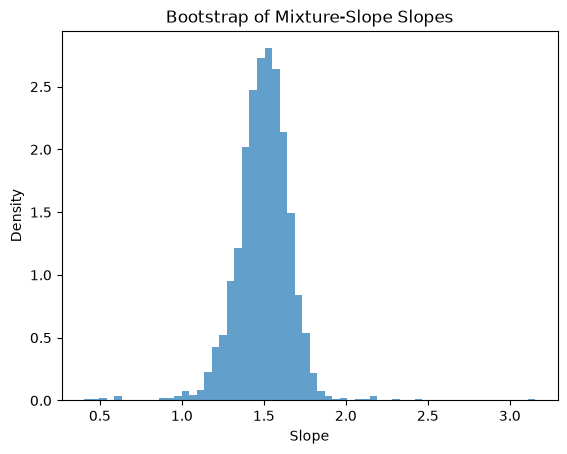

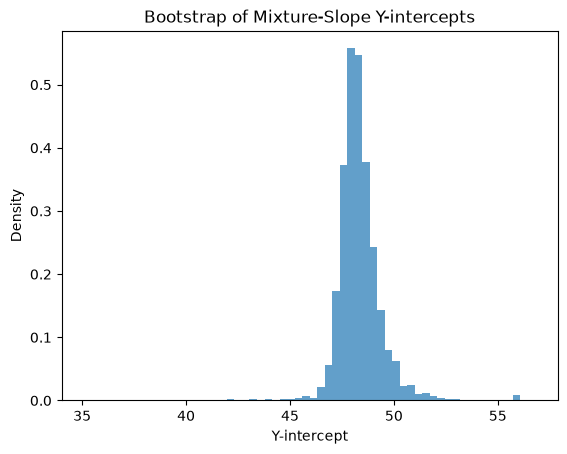

In [171]:
random_seed = np.random.default_rng(20260902)
n_boot = 2000

# resample (x, y) PAIRS with replacement, refit Mixture-Method each time
boot_slopes = np.empty(n_boot)
boot_intercepts = np.empty(n_boot)

for j in range(n_boot):
    idx = random_seed.integers(0, n, size=n)
    result = minimize(neg_log_likelihood, theta0, args=(x[idx], y[idx], sigma[idx]), method='Nelder-Mead')
    m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x
    boot_slopes[j] = m_mix
    boot_intercepts[j] = b_mix

plt.figure(1)
plt.hist(boot_slopes, bins=60, density=True, alpha=0.7)
plt.title('Bootstrap of Mixture-Slope Slopes')
plt.ylabel('Density')
plt.xlabel('Slope')
lo, hi = np.percentile(boot_slopes, [16, 84])
print(f"bootstrap 68% interval slopes = [{lo:.2f}, {hi:.2f}]")
print(f'Slope range: \u00B1 {((hi - lo)/2):.3f}')

print('')

plt.figure(2)
plt.hist(boot_intercepts, bins=60, density=True, alpha=0.7)
plt.title('Bootstrap of Mixture-Slope Y-intercepts')
plt.ylabel('Density')
plt.xlabel('Y-intercept')
lo, hi = np.percentile(boot_intercepts, [16, 84])
print(f"bootstrap 68% interval Y-intercepts = [{lo:.2f}, {hi:.2f}]")
print(f'Slope range: \u00B1 {((hi - lo)/2):.3f}')

In [278]:
print('Final Calculated Values:')
print('Slope: 1.510 \u00B1 .138 km/(s*night)')
print('Y-intercept: 48.253 \u00B1 .759 km/s')

Final Calculated Values:
Slope: 1.510 ± .138 km/(s*night)
Y-intercept: 48.253 ± .759 km/s


**FINAL ANSWER:** $m = $ 1.510 $\pm$ .138 km/(s * night), $b = $ 48.253 $\pm$ .759 km/s, outlier fraction $\approx$ .167

**Justification and uncertainty method (a short paragraph):**

*To calculate these values I used a Mixture-Method to calculate the slope as two populations coming from the data at once; a good population centered as a gaussian around a line and a bad population with its own varience and mean independent of the good data. I measured the uncertainties in this model by running a bootstrap of the model and returning the parameters I get from the model each time. I then found where 68% of the data lay and used this to determine the greatest and smallest values in this range to determine the $\pm$ gap. I trust these uncertainties more as this calculation doesn't include an arbitraily chosen sigma value (like in the sigma-clipping method) so it includes less bias. I trust this value more as I can explicitly see the spread of slopes and intercepts. This value is also determined by 2000 repetitions instead of just 1 attempt, making the range more representitive of how the range looks.*

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong — in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset — show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1: The Ai model doesn't weight its errors by 1/sigma*

*Flaw 2: The Ai model clips once rather than converging on the k-sigma clip*

*Flaw 3: The Ai model rescales Chi-square so that it is equal in size to 1 rather than accepting value as is*

Slope: 1.298 ± 0.119
Y-intercept: 47.737 ± 0.718

Ai Slope: 1.308 ± 0.506
Ai Y-intercept: 46.875 ± 3.400


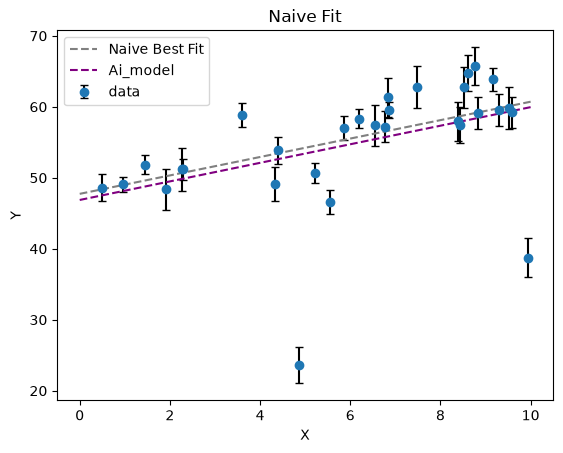

In [279]:
# Part 3:
#Flaw 1:
wls_bad = np.polyfit(x, y, 1, cov = True)
n_fit_bad = wls_bad[0][0] * xx + wls_bad[0][1]


print(f'Slope: {wls[0][0]:.3f} \u00B1 {np.sqrt(wls[1][0][0]):.3f}')
print(f'Y-intercept: {wls[0][1]:.3f} \u00B1 {np.sqrt(wls[1][1][1]):.3f}')
print('')
print(f'Ai Slope: {wls_bad[0][0]:.3f} \u00B1 {np.sqrt(wls_bad[1][0][0]):.3f}')
print(f'Ai Y-intercept: {wls_bad[0][1]:.3f} \u00B1 {np.sqrt(wls_bad[1][1][1]):.3f}')

plt.errorbar(x, y, yerr = sigma, fmt = 'o', ecolor = 'black', capsize = 3, label = 'data')
plt.title('Naive Fit')
plt.plot(xx, n_fit, label = 'Naive Best Fit', color = 'grey', linestyle = '--')
plt.plot(xx, n_fit_bad, color = 'purple', linestyle = '--', label = 'Ai_model')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

This Ai model does not include a weighting for its model fit. Since the model isn't weighted by the uncertainties the estimated value won't take the errors in the points into consideration. This causes the two outliers lower down on the graph to have a greater impact on the fit location as they will have just as much impact on the fit line as any other point. The correct treatment is to pass the np.polyfit function a value for w (1/sigma) as this will require the software to include a weighting attribute the fits shape to the uncertainties.

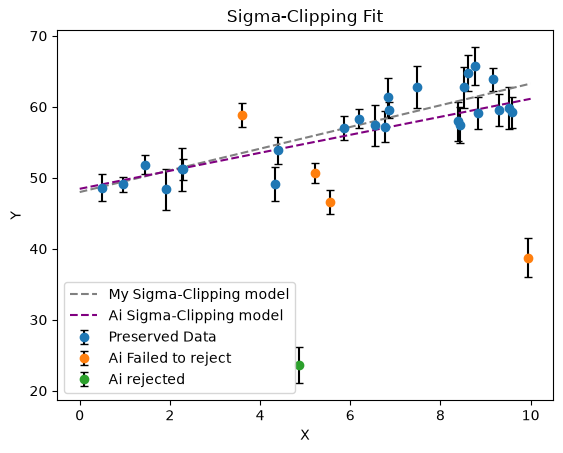

In [280]:
#Flaw 2:
plt.figure(1)
Ai_residuals = y - (wls[0][0] * x + wls[0][1])
Ai_threshold = 3 * np.std(residuals)
Ai_mask = np.abs(residuals) < threshold

coeffs, cov = np.polyfit(x[Ai_mask], y[Ai_mask], 1, w= 1/sigma[Ai_mask], cov = 'unscaled')
m_fit, b_fit = coeffs
m_err, b_err = np.sqrt(np.diag(cov))

fails_to_catch = (Ai_mask & ~mask)

plt.errorbar(x[mask], y[mask], yerr = sigma[mask], fmt = 'o', ecolor = 'black', capsize = 3, label = 'Preserved Data')
plt.errorbar(x[fails_to_catch], y[fails_to_catch], yerr = sigma[fails_to_catch],
             fmt = 'o', ecolor = 'black', capsize = 3, label = 'Ai Failed to reject')
plt.errorbar(x[~Ai_mask], y[~Ai_mask], yerr = sigma[~Ai_mask],
             fmt = 'o', ecolor = 'black', capsize = 3, label = 'Ai rejected')

plt.plot(xx, sc_fit, color = 'grey', linestyle = '--', label = 'My Sigma-Clipping model')
plt.plot(xx, coeffs[0] * xx + coeffs[1], color = 'purple', linestyle = '--', label = 'Ai Sigma-Clipping model')

plt.title('Sigma-Clipping Fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

Using the Ai model's Sigma clipping attempt, the model rejects too few values from the sigma clip. This is as the model only rejects points that are initially 3 sigma away. This attempt fails to continue to iterativly reject values until it converges on an answer. Due to this, the model includes too many outliers. As many of the outliers are below the fit line, this drags the predicted slope value down to include these outliers. The correct treatment of this problem is to continue to iterativly clip points until it converges on a value. 

In [301]:
Ai_chi2 = np.sum(((y[mask] - (sc[0][0] * x[mask] + sc[0][1])) / sigma[mask])**2)
dof = mask.sum() - 2
Ai_chi2_red = Ai_chi2 / dof
print(f"Ai Reduced chi-squared: {Ai_chi2_red:.3f}")

scale = np.sqrt(Ai_chi2_red)
sigma_scaled = sigma * scale
chi2_new = np.sum(((y[mask] - (sc[0][0] * x[mask] + sc[0][1])) / sigma_scaled[mask])**2) / dof
m_err, b_err = m_err * scale, b_err * scale
print(f"After rescaling uncertainties by {scale:.3f}: reduced chi-squared = {chi2_new:.3f}")
print("The fit is now fully consistent with the data.")

print('')

print(f'My reduced chi-squared: {Chi2_Clipped:.3f}')

Ai Reduced chi-squared: 1.181
After rescaling uncertainties by 1.087: reduced chi-squared = 1.000
The fit is now fully consistent with the data.

My reduced chi-squared: 1.181


Having the Ai model scale the value by the sqrt of the reduced Chi2 value results in a scale value that forces the model to be equal to 1. This step skews your Chi2 value; rather than accepting the value for what it is, the Ai model forces the answer to be 1. Doing this causes the Chi-squared value to no longer represent the variation in the data but instead just equal 1. The correct treatment of this issue is to just take the reduced Chi-squared value as initially calculated and report it as is rather than scaling it. 

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

*The only Ai tool I used on this assignment was Google's Ai overview. I didn't explicitly copy any of the code that was returned - I just used this was to look up methods that I could verify with the method's documentation so that I could use them in the way I intended for them to be used.*

**VERIFICATION PLAN:**

1) Refitting on synthetic Data

2) Comparing my model to packaged model

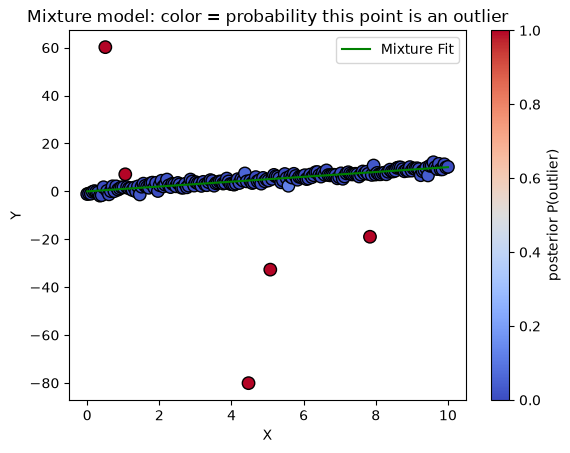

In [344]:
#1
pop1 = np.random.normal(loc = xx)
pop2 = 50 * np.random.normal(size = 5)

pop1[10] = pop2[0]
pop1[21] = pop2[1]
pop1[89] = pop2[2]
pop1[101] = pop2[3]
pop1[156] = pop2[4]


Synth_theta0 = [1, 0, 5/100, np.mean(pop1), np.log(50.0)]
Synth_result = minimize(neg_log_likelihood, Synth_theta0, args=(xx, pop1, 1), method='Nelder-Mead')
m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = Synth_result.x

Vb_mix = np.exp(lnVb_mix)
model_mix = m_mix * xx + b_mix
good_l = (1 - Pb_mix) * norm.pdf(pop1, loc=model_mix, scale=1)
bad_l = Pb_mix * norm.pdf(pop1, loc=Yb_mix, scale=np.sqrt(Vb_mix + 1**2))
p_bad = bad_l / (good_l + bad_l)


plt.scatter(xx, pop1, c = p_bad, cmap='coolwarm', s=80, edgecolor='k', vmin=0, vmax=1)
plt.colorbar(label='posterior P(outlier)')
plt.plot(xx, m_mix * xx + b_mix, 'g-', label='Mixture Fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Mixture model: color = probability this point is an outlier')
plt.legend()
plt.show()

To verify my data I created a line and then used np.random.normal to create a gaussian about a line. I then changed 5 of the points to instead be points about a gaussian that isn't influenced by the line. In doing this I created a model that I could test my Mixed-Mixture algorithm against. Since the mixture algorithm assumes your model is made up of a gaussian centered about a line and another gaussian independent of the line, the mixture model should be able to pick out the two distinct populations. In this instance a success is finding that the points from population 2 are outliers (which it sucessfully does). A failure would have been if the a significant amount of the data that was centered along the straight line was also being flagged as an outlier.

In [347]:
#2
from scipy.stats import theilslopes

m_ts, b_ts, lo_ts, hi_ts = theilslopes(y, x)
print(f"Theil-Sen: slope = {m_ts:.3f} (95% CI [{lo_ts:.3f}, {hi_ts:.3f}]), intercept = {b_ts:.3f}")

Theil-Sen: slope = 1.446 (95% CI [0.987, 1.979]), intercept = 47.774


To help build cofidence in my model, I compared my results to scipy's theilslopes fitter to see the fitter's 95% confidence range and see if it yielded a similar magnitude result. A failure of verification would be if my value was outside the 95% confidence interval or if my value was orders of magnitude different from the Theilslopes model as a 95% interval covers most of the range of values I may have and my value should converge to a similar predicted value as other slope finders. As it is, my value resides within the 95% confidence interval and the Theil-Sen model yields a result that is within my errors. 